In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
from google.colab import files
uploaded=files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv


In [3]:

dataset = pd.read_csv('/content/HR_comma_sep.csv')
dataset.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


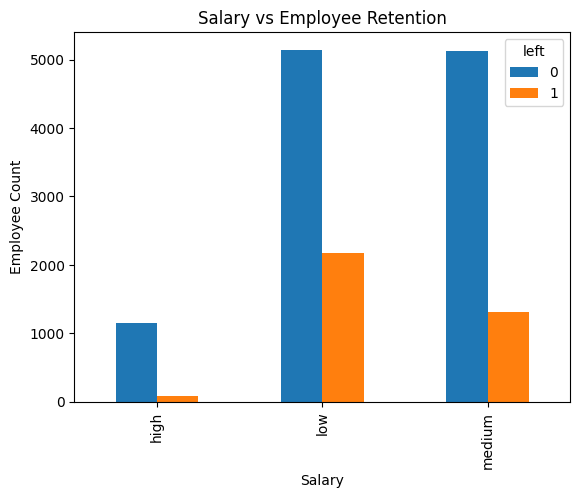

In [4]:

pd.crosstab(dataset.salary, dataset.left).plot(kind='bar')
plt.xlabel("Salary")
plt.ylabel("Employee Count")
plt.title("Salary vs Employee Retention")
plt.show()

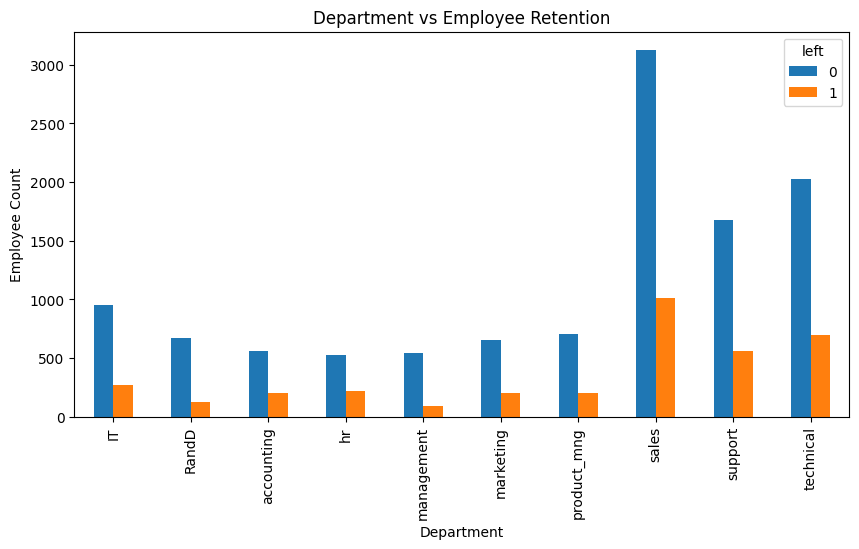

In [5]:
pd.crosstab(dataset.Department, dataset.left).plot(kind='bar', figsize=(10,5))
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.title("Department vs Employee Retention")
plt.show()

In [6]:
subdata = dataset[['satisfaction_level',
                   'average_montly_hours',
                   'promotion_last_5years',
                   'salary']]


In [7]:
salary_dummies = pd.get_dummies(subdata.salary, prefix='salary')
salary_dummies = salary_dummies.astype(int)

In [8]:
data = pd.concat([subdata, salary_dummies], axis=1)
data.drop('salary', axis=1, inplace=True)
data.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,0,1,0
1,0.80,262,0,0,0,1
2,0.11,272,0,0,0,1
3,0.72,223,0,0,1,0
4,0.37,159,0,0,1,0


In [9]:
X = data
y = dataset.left

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)


In [10]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("Accuracy Percentage :", accuracy*100)



Accuracy : 0.762
Accuracy Percentage : 76.2
